# Titanic Dataset — Exploratory Data Analysis (EDA)

---

## Project Overview

The **RMS Titanic** sank on April 15, 1912, after colliding with an iceberg — one of the deadliest peacetime maritime disasters in history. Of the estimated **2,224 passengers and crew** aboard, more than **1,500 perished**.

In this project, I performed a complete **Exploratory Data Analysis (EDA)** on the Titanic passenger dataset to uncover:
- The **demographic profile** of passengers
- **Survival patterns** across gender, class, and age
- Key **statistical insights** and **visualizations**

---

---
## 1. Importing Libraries <a id='1'></a>

We begin by importing all the necessary Python libraries:
- **`pandas`** — data manipulation and analysis
- **`numpy`** — numerical operations
- **`matplotlib`** — base plotting library
- **`seaborn`** — statistical data visualization (built on top of Matplotlib)

We also configure display settings for cleaner output.

In [1]:
# ── Standard library imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# ── Display & style configuration ────────────────────────────────────────────
warnings.filterwarnings('ignore')            # suppress non-critical warnings
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# ── Matplotlib / Seaborn global style ────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ All libraries imported successfully!
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


---
## 2. Loading the Dataset <a id='2'></a>

The Titanic dataset is built into the **Seaborn** library, so no external download is needed.  
We load it directly and inspect the first few rows to get an initial sense of the data.

In [2]:
# ── Load the Titanic dataset from seaborn ─────────────────────────────────────
df = sns.load_dataset('titanic')

print(f'✅ Dataset loaded successfully!')
print(f'   Rows    : {df.shape[0]}')
print(f'   Columns : {df.shape[1]}')

✅ Dataset loaded successfully!
   Rows    : 891
   Columns : 15


In [3]:
# ── Preview the first 5 rows ──────────────────────────────────────────────────
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# ── Preview the last 5 rows ───────────────────────────────────────────────────
print('Last 5 rows of the dataset:')
df.tail()

Last 5 rows of the dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.00,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.00,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.00,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.00,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


---
## 3. Dataset Overview <a id='3'></a>

Before analysing, let's understand the **structure** of the dataset:

| Column | Description |
|---|---|
| `survived` | 0 = Did not survive, 1 = Survived |
| `pclass` | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `sex` | Passenger gender |
| `age` | Passenger age in years |
| `sibsp` | # of siblings / spouses aboard |
| `parch` | # of parents / children aboard |
| `fare` | Passenger fare paid |
| `embarked` | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |
| `class` | Ticket class (string version of pclass) |
| `who` | Category: man / woman / child |
| `adult_male` | Boolean — adult male flag |
| `deck` | Deck level (cabin letter) |
| `embark_town` | Full embarkation town name |
| `alive` | yes / no (string version of survived) |
| `alone` | Boolean — travelling alone flag |

In [5]:
# ── Dataset shape ─────────────────────────────────────────────────────────────
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset Shape: 891 rows × 15 columns


In [6]:
# ── Column names and data types ───────────────────────────────────────────────
print('Column Information:')
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
# ── Count unique values per column ───────────────────────────────────────────
print('Unique values per column:')
df.nunique().to_frame(name='Unique Values')

Unique values per column:


,Unique Values
survived,2
pclass,3
sex,2
age,88
sibsp,7
parch,7
fare,248
embarked,3
class,3
who,3


---
## 4. Statistical Summary <a id='4'></a>

A statistical summary helps us understand the **central tendency**, **spread**, and **range** of numerical features at a glance.

In [8]:
# ── Descriptive statistics for numeric columns ────────────────────────────────
print('Statistical Summary (Numerical Features):')
df.describe().T.style.background_gradient(cmap='Blues')

Statistical Summary (Numerical Features):


,count,mean,std,min,25%,50%,75%,max
survived,891.000000,0.383838,0.486592,0.000000,0.000000,0.000000,1.000000,1.000000
pclass,891.000000,2.308642,0.836071,1.000000,2.000000,3.000000,3.000000,3.000000
age,714.000000,29.699118,14.526497,0.420000,20.125000,28.000000,38.000000,80.000000
sibsp,891.000000,0.523008,1.102743,0.000000,0.000000,0.000000,1.000000,8.000000
parch,891.000000,0.381594,0.806057,0.000000,0.000000,0.000000,0.000000,6.000000
fare,891.000000,32.204208,49.693429,0.000000,7.910400,14.454200,31.000000,512.329200


In [9]:
# ── Descriptive statistics for categorical columns ────────────────────────────
print('Statistical Summary (Categorical Features):')
df.describe(include='object')

Statistical Summary (Categorical Features):


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


> **Insight:** The average passenger age was ~29.7 years. The fare varied wildly — from \$0 to \$512, indicating a huge disparity between cabin classes.

---
## 5. Missing Value Analysis <a id='5'></a>

Missing data is one of the most common real-world data quality issues. Let's identify columns with nulls and visualise their extent.

In [10]:
# ── Count and percentage of missing values ────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':    (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
missing

Columns with missing values:


,Missing Count,Missing %
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


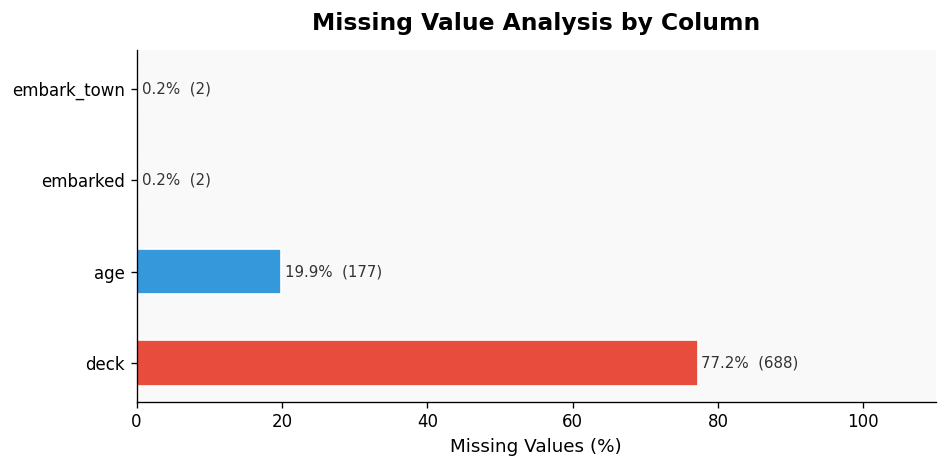

📊 Figure 1: Missing Value Analysis


In [11]:
# ── Visualise missing values as a bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#e74c3c' if v > 50 else '#e67e22' if v > 20 else '#3498db'
          for v in missing['Missing %']]

bars = ax.barh(missing.index, missing['Missing %'], color=colors, edgecolor='white', height=0.5)

# Annotate each bar
for bar, (_, row) in zip(bars, missing.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{row['Missing %']:.1f}%  ({int(row['Missing Count'])})",
            va='center', fontsize=9, color='#333')

ax.set_xlabel('Missing Values (%)', fontsize=11)
ax.set_title('Missing Value Analysis by Column', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig('fig1_missing_values.png', bbox_inches='tight')
plt.show()
print('📊 Figure 1: Missing Value Analysis')

> **Insight:** `deck` is missing for ~77% of passengers — too incomplete to impute reliably. `age` is missing for ~20% and needs careful imputation. `embark_town` and `embarked` are missing for only 2 rows.

---
## 6. Data Cleaning <a id='6'></a>

We handle missing values using domain-appropriate strategies:
- **`age`** → imputed with the **median** (robust to outliers)
- **`embarked` / `embark_town`** → imputed with the **mode** (most frequent)
- **`deck`** → dropped (>77% missing, not suitable for imputation)
- Duplicate columns (`alive`, `class`, `who`, `adult_male`) are dropped or retained based on analytical need.

In [13]:
# ── Make a working copy to preserve the original ──────────────────────────────
df_clean = df.copy()

# 1. Impute 'age' with median
age_median = df_clean['age'].median()
df_clean['age'].fillna(age_median, inplace=True)
print(f'   age    → filled with median ({age_median:.1f})')

# 2. Impute 'embarked' and 'embark_town' with mode
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0], inplace=True)
print(f'   embarked / embark_town → filled with mode')

# 3. Drop 'deck' — too many nulls
df_clean.drop(columns=['deck'], inplace=True)
print(f'   deck   → column dropped (>77% missing)')

# 4. Verify — no remaining nulls (except none expected)
remaining_nulls = df_clean.isnull().sum().sum()
print(f'\n✅ Cleaning complete! Remaining null values: {remaining_nulls}')
print(f'   Final dataset shape: {df_clean.shape}')

   age    → filled with median (28.0)
   embarked / embark_town → filled with mode
   deck   → column dropped (>77% missing)

✅ Cleaning complete! Remaining null values: 0
   Final dataset shape: (891, 14)


In [14]:
# ── Check for duplicate rows ──────────────────────────────────────────────────
dupes = df_clean.duplicated().sum()
print(f'Duplicate rows: {dupes}')

# ── Age group binning for later analysis ─────────────────────────────────────
bins   = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels)
print('✅ Age group feature created:', df_clean['age_group'].value_counts().to_dict())

Duplicate rows: 116
✅ Age group feature created: {'Young Adult': 535, 'Adult': 195, 'Teen': 70, 'Child': 69, 'Senior': 22}


---
## 7. Univariate Analysis <a id='7'></a>

**Univariate analysis** examines **one variable at a time** to understand its distribution, frequency, and spread.

### 7.1 Age Distribution

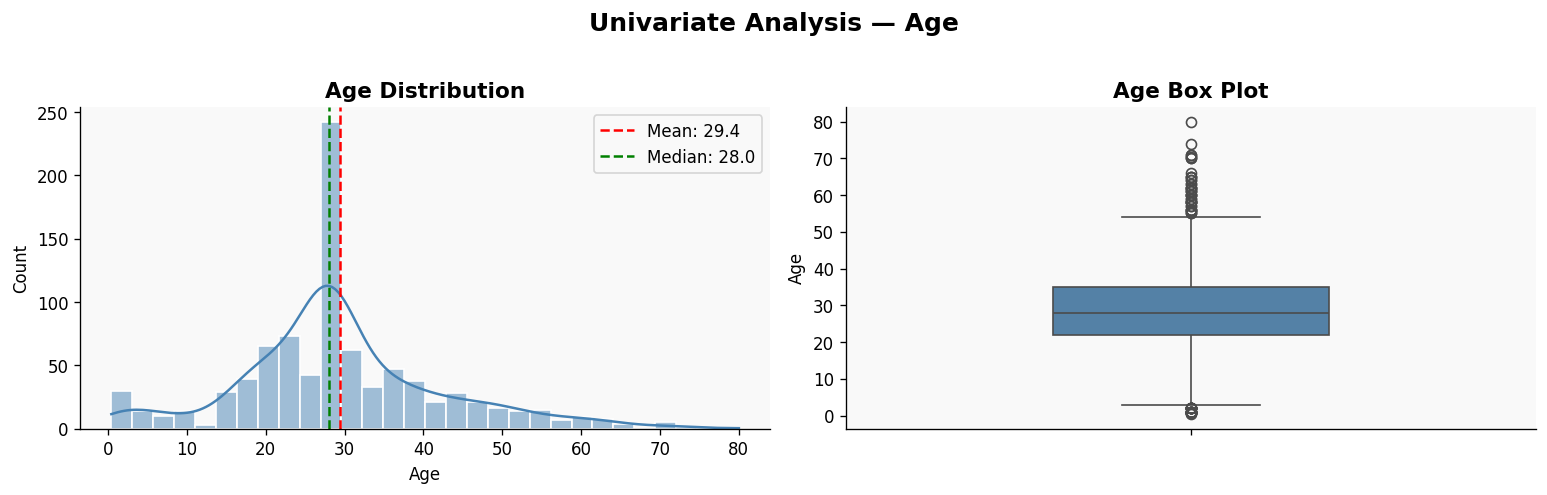

📊 Figure 2: Age Distribution


In [15]:
# ── Fig 2: Age distribution histogram with KDE ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram + KDE
sns.histplot(df_clean['age'], bins=30, kde=True, color='steelblue',
             edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['age'].mean(),   color='red',    linestyle='--', label=f"Mean: {df_clean['age'].mean():.1f}")
axes[0].axvline(df_clean['age'].median(), color='green',  linestyle='--', label=f"Median: {df_clean['age'].median():.1f}")
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
sns.boxplot(y=df_clean['age'], color='steelblue', ax=axes[1], width=0.4)
axes[1].set_title('Age Box Plot', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Univariate Analysis — Age', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_age_distribution.png', bbox_inches='tight')
plt.show()
print('📊 Figure 2: Age Distribution')

> **Insight:** The age distribution is **right-skewed**. Most passengers were between **20–40 years old**. The median (28) is lower than the mean (29.7), confirming mild skewness. A notable peak of infants and young children is also visible.

### 7.2 Fare Distribution

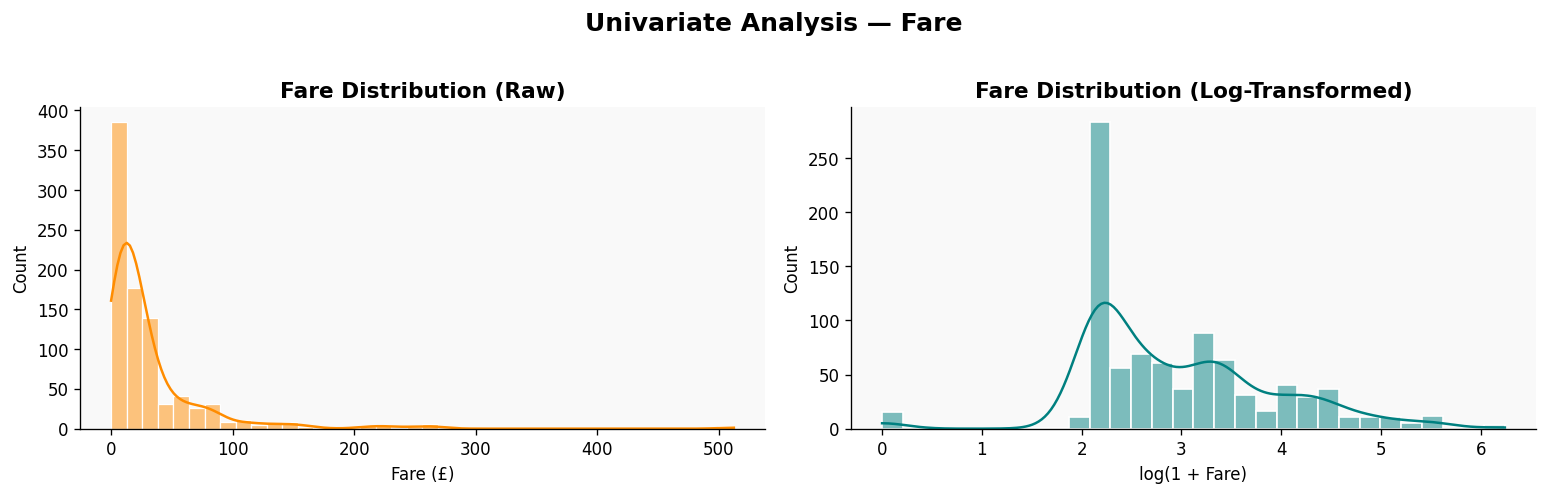

📊 Figure 3: Fare Distribution


In [16]:
# ── Fig 3: Fare distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_clean['fare'], bins=40, kde=True, color='darkorange',
             edgecolor='white', ax=axes[0])
axes[0].set_title('Fare Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare (£)')

sns.histplot(np.log1p(df_clean['fare']), bins=30, kde=True, color='teal',
             edgecolor='white', ax=axes[1])
axes[1].set_title('Fare Distribution (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')

plt.suptitle('Univariate Analysis — Fare', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_fare_distribution.png', bbox_inches='tight')
plt.show()
print('📊 Figure 3: Fare Distribution')

> **Insight:** Fare is **heavily right-skewed** with extreme outliers (some passengers paid over £500). After a log-transform, the distribution becomes approximately bell-shaped — useful for modelling.

### 7.3 Categorical Distributions

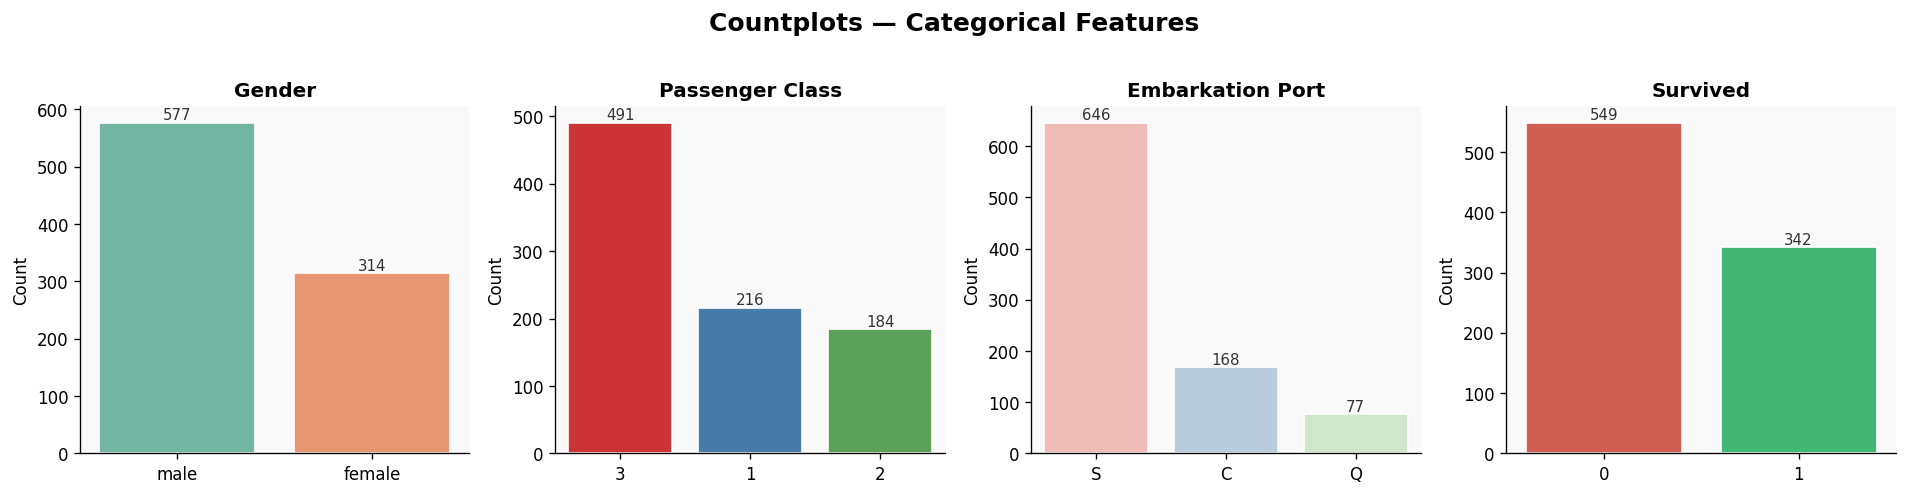

📊 Figure 4: Countplots


In [17]:
# ── Fig 4: Countplots for categorical features ────────────────────────────────
cat_cols = ['sex', 'pclass', 'embarked', 'survived']
titles   = ['Gender', 'Passenger Class', 'Embarkation Port', 'Survived']
palette  = ['Set2', 'Set1', 'Pastel1', ['#e74c3c', '#2ecc71']]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col, title, pal in zip(axes, cat_cols, titles, palette):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, order=order, palette=pal, ax=ax,
                  edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    # Add count labels on bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9, color='#333')

plt.suptitle('Countplots — Categorical Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_countplots.png', bbox_inches='tight')
plt.show()
print('📊 Figure 4: Countplots')

> **Insight:** Males outnumber females nearly **2:1**. Over **55% of passengers** were in 3rd class. Southampton was the dominant embarkation port (~72%). Only **342 out of 891 passengers (38.4%) survived**.

### 7.4 Pie Charts — Gender & Embarkation

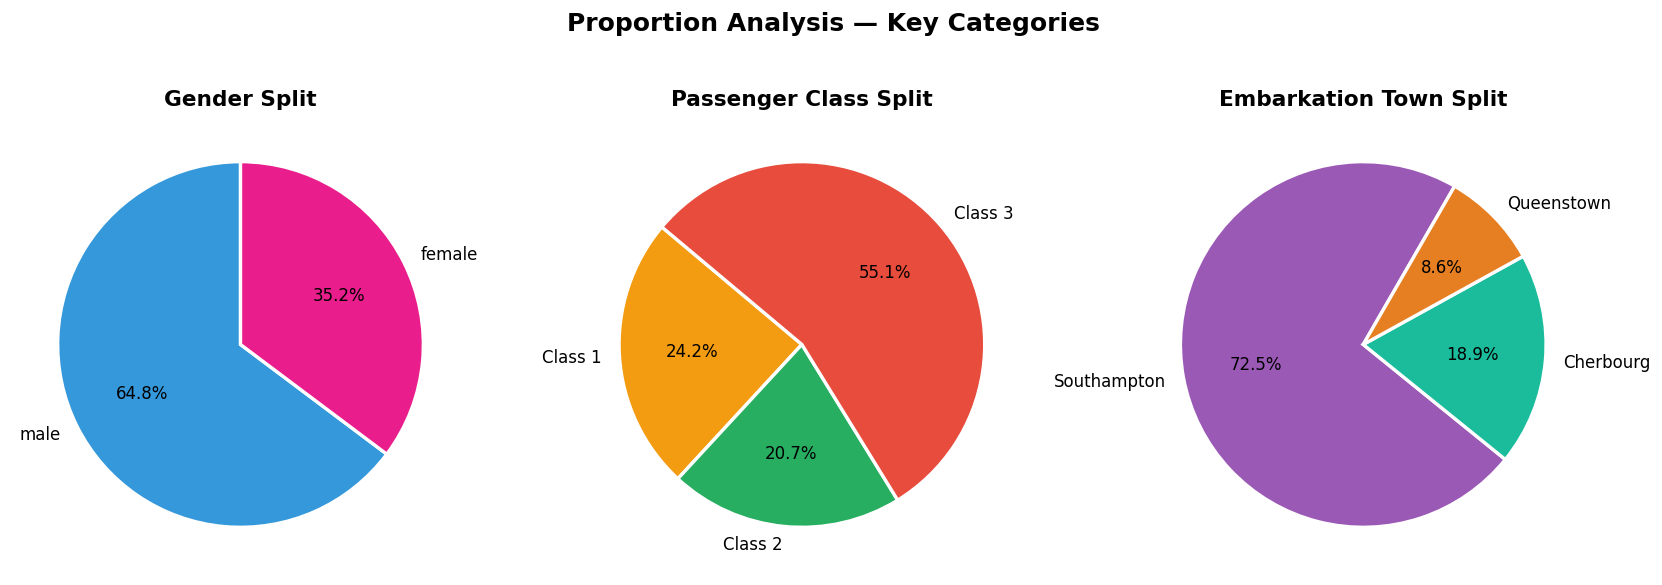

📊 Figure 5: Pie Charts


In [18]:
# ── Fig 5: Pie charts ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gender pie
sex_counts = df_clean['sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e91e8c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Gender Split', fontsize=13, fontweight='bold')

# Class pie
class_counts = df_clean['pclass'].value_counts().sort_index()
axes[1].pie(class_counts, labels=[f'Class {c}' for c in class_counts.index],
            autopct='%1.1f%%', colors=['#f39c12', '#27ae60', '#e74c3c'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Passenger Class Split', fontsize=13, fontweight='bold')

# Embarkation pie
emb_counts = df_clean['embark_town'].value_counts()
axes[2].pie(emb_counts, labels=emb_counts.index, autopct='%1.1f%%',
            colors=['#9b59b6', '#1abc9c', '#e67e22'],
            startangle=60, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Embarkation Town Split', fontsize=13, fontweight='bold')

plt.suptitle('Proportion Analysis — Key Categories', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_pie_charts.png', bbox_inches='tight')
plt.show()
print('📊 Figure 5: Pie Charts')

---
## 8.  Bivariate Analysis <a id='8'></a>

**Bivariate analysis** explores the **relationship between two variables**, helping us understand how features interact with each other and with the target variable (`survived`).

### 8.1 Age vs Fare (with Survival)

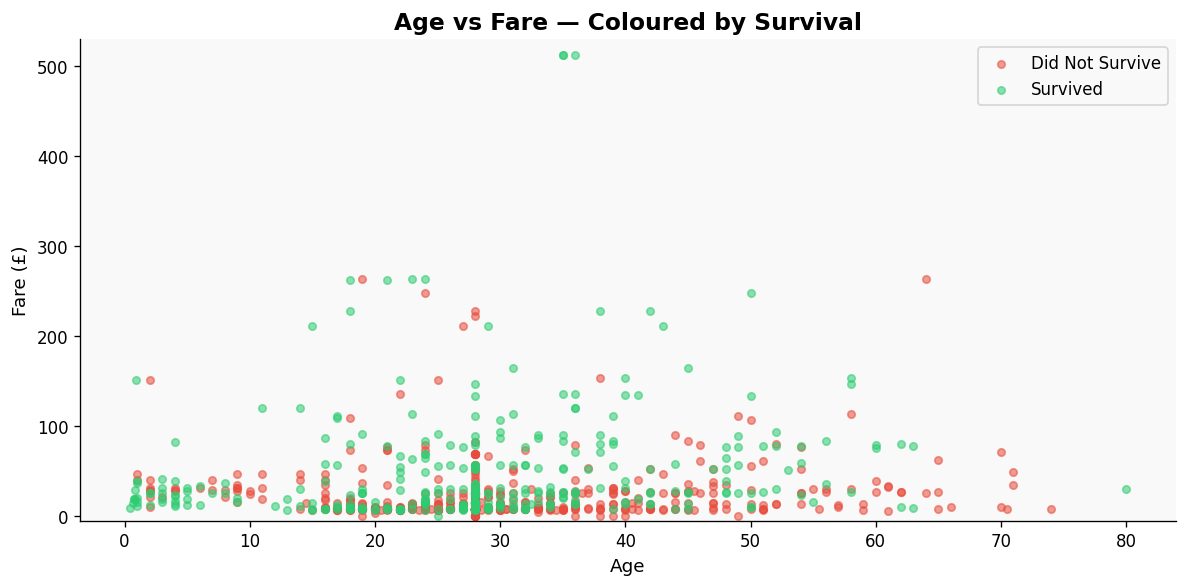

📊 Figure 6: Age vs Fare Scatter


In [19]:
# ── Fig 6: Scatter plot — Age vs Fare coloured by Survival ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {0: '#e74c3c', 1: '#2ecc71'}
for survived, grp in df_clean.groupby('survived'):
    ax.scatter(grp['age'], grp['fare'],
               c=colors_map[survived], alpha=0.55, s=20,
               label='Survived' if survived == 1 else 'Did Not Survive')

ax.set_xlabel('Age', fontsize=11)
ax.set_ylabel('Fare (£)', fontsize=11)
ax.set_title('Age vs Fare — Coloured by Survival', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-5, 530)

plt.tight_layout()
plt.savefig('fig6_age_vs_fare.png', bbox_inches='tight')
plt.show()
print('📊 Figure 6: Age vs Fare Scatter')

> **Insight:** Passengers who **paid higher fares** (1st class) were more likely to survive. There's no single age threshold for survival, but children (age < 12) show better survival rates at lower fare levels.

### 8.2 Survival by Passenger Class

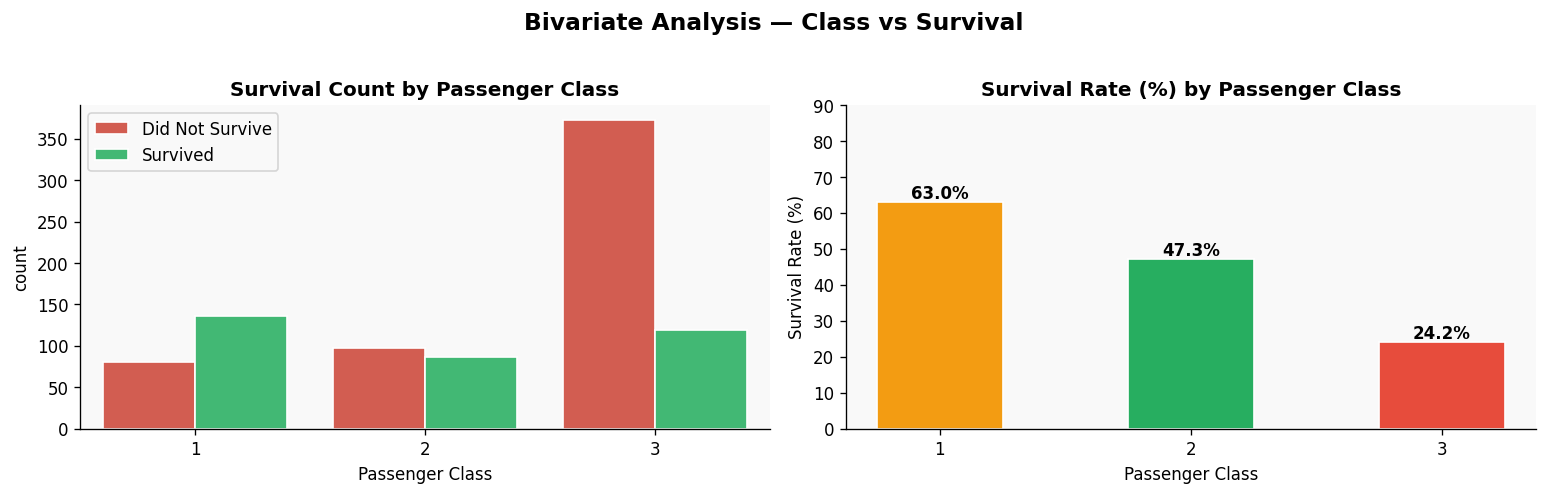

📊 Figure 7: Class vs Survival


In [20]:
# ── Fig 7: Grouped bar — Survival count by class ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count
sns.countplot(data=df_clean, x='pclass', hue='survived',
              palette=['#e74c3c', '#2ecc71'], edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Count by Passenger Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].legend(['Did Not Survive', 'Survived'])

# Rate
survival_rate = df_clean.groupby('pclass')['survived'].mean().reset_index()
survival_rate['survived'] *= 100
bars = axes[1].bar(survival_rate['pclass'].astype(str),
                   survival_rate['survived'],
                   color=['#f39c12', '#27ae60', '#e74c3c'], edgecolor='white', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Survival Rate (%) by Passenger Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 90)

plt.suptitle('Bivariate Analysis — Class vs Survival', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_class_survival.png', bbox_inches='tight')
plt.show()
print('📊 Figure 7: Class vs Survival')

> **Insight:** Survival rate drops dramatically with class: **1st class: ~63%**, **2nd class: ~47%**, **3rd class: ~24%**. Economic status strongly predicted survival.

### 8.3 Survival by Gender

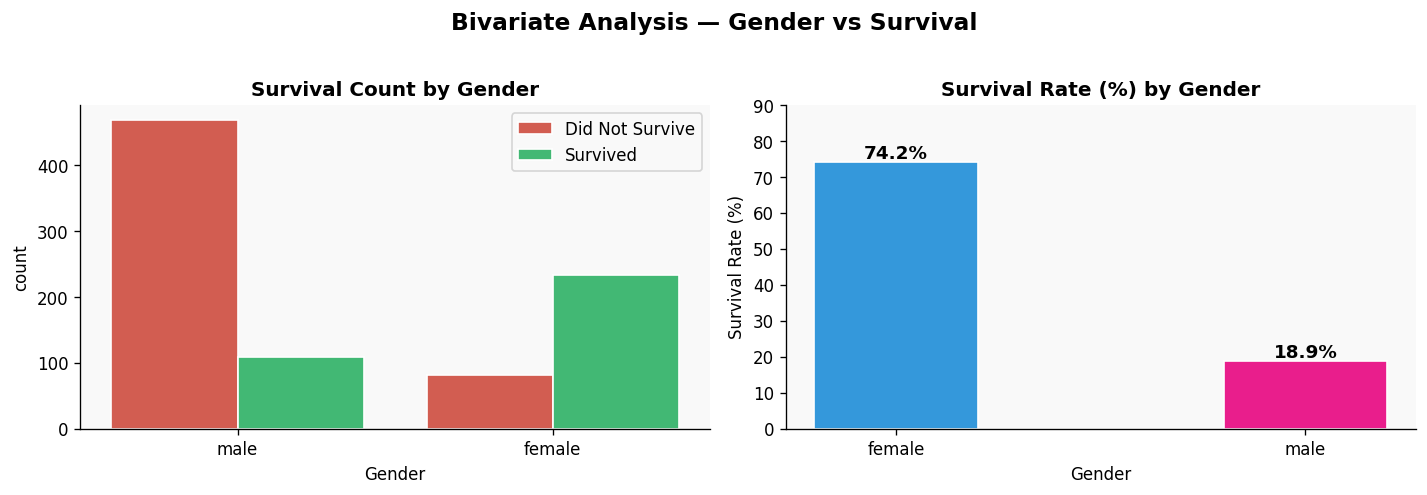

📊 Figure 8: Gender vs Survival


In [21]:
# ── Fig 8: Gender vs Survival ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_clean, x='sex', hue='survived',
              palette=['#e74c3c', '#2ecc71'], edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Count by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate by gender
gen_rate = df_clean.groupby('sex')['survived'].mean().reset_index()
gen_rate['survived'] *= 100
axes[1].bar(gen_rate['sex'], gen_rate['survived'],
            color=['#3498db', '#e91e8c'], edgecolor='white', width=0.4)
for i, row in gen_rate.iterrows():
    axes[1].text(i, row['survived'] + 1, f"{row['survived']:.1f}%",
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Survival Rate (%) by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 90)

plt.suptitle('Bivariate Analysis — Gender vs Survival', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_gender_survival.png', bbox_inches='tight')
plt.show()
print('📊 Figure 8: Gender vs Survival')

> **Insight:** **"Women and children first"** is clearly reflected in the data. Female survival rate is **~74%** vs only **~19%** for males — the single strongest predictor of survival.

### 8.4 Survival by Age Group

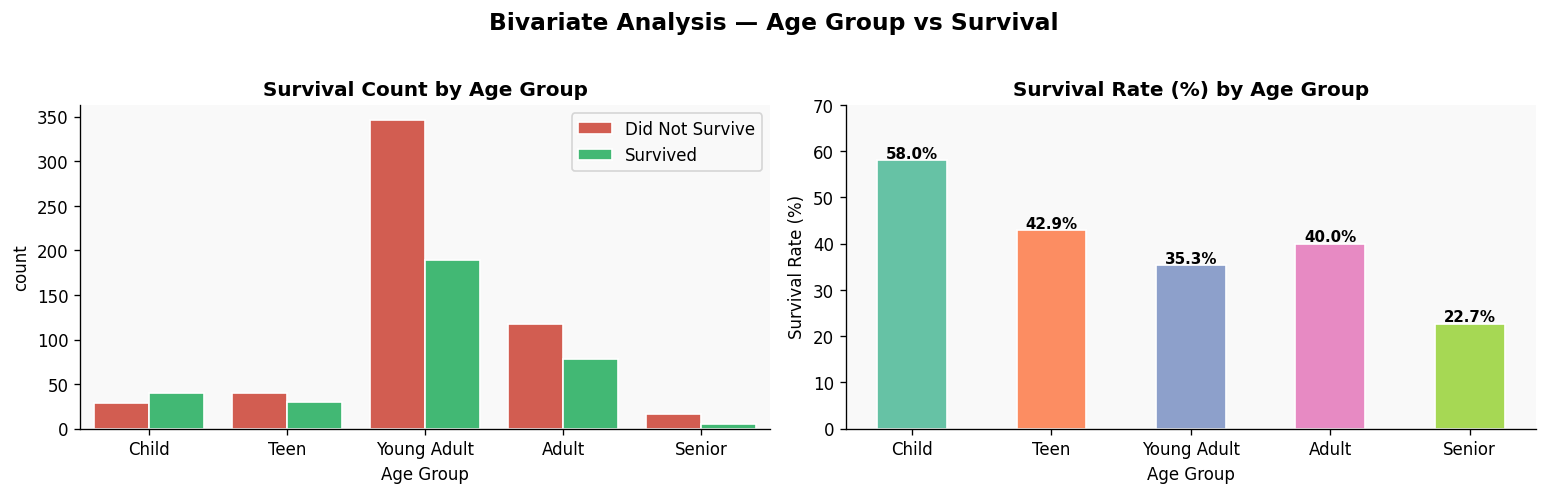

📊 Figure 9: Age Group vs Survival


In [22]:
# ── Fig 9: Age group vs Survival ──────────────────────────────────────────────
age_survival = df_clean.groupby('age_group', observed=True)['survived'].agg(
    count='count', survived_count='sum'
).reset_index()
age_survival['survival_rate'] = (age_survival['survived_count'] / age_survival['count'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stacked bar
sns.countplot(data=df_clean, x='age_group', hue='survived', order=labels,
              palette=['#e74c3c', '#2ecc71'], edgecolor='white', ax=axes[0])
axes[0].set_title('Survival Count by Age Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].legend(['Did Not Survive', 'Survived'])

# Survival rate line
axes[1].bar(age_survival['age_group'].astype(str),
            age_survival['survival_rate'],
            color=sns.color_palette('Set2', len(age_survival)), edgecolor='white', width=0.5)
for i, row in age_survival.iterrows():
    axes[1].text(i, row['survival_rate'] + 0.5, f"{row['survival_rate']}%",
                 ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Survival Rate (%) by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 70)

plt.suptitle('Bivariate Analysis — Age Group vs Survival', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig9_agegroup_survival.png', bbox_inches='tight')
plt.show()
print('📊 Figure 9: Age Group vs Survival')

> **Insight:** **Children had the highest survival rate** (~59%), supporting the "women and children first" evacuation policy. Seniors (60+) had the lowest survival rate among age groups.

---
## 9. Correlation Heatmap <a id='9'></a>

A **correlation heatmap** shows the **Pearson correlation coefficient** between all pairs of numeric features. Values range from **-1** (perfect negative) to **+1** (perfect positive), with **0** indicating no linear relationship.

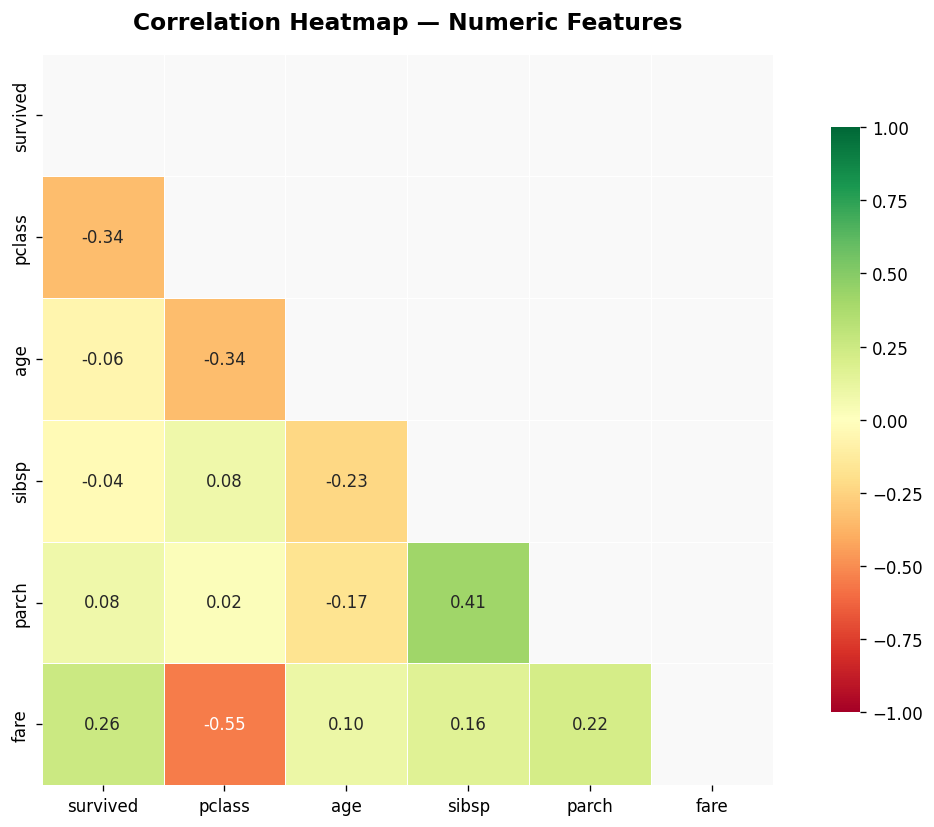

📊 Figure 11: Correlation Heatmap


In [24]:
# ── Fig 11: Correlation Heatmap ───────────────────────────────────────────────
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig11_heatmap.png', bbox_inches='tight')
plt.show()
print('📊 Figure 11: Correlation Heatmap')

In [25]:
# ── Top correlations with 'survived' ─────────────────────────────────────────
print('Top correlations with "survived":')
corr_survived = corr_matrix['survived'].drop('survived').sort_values(key=abs, ascending=False)
corr_survived.to_frame().style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1)

Top correlations with "survived":


,survived
pclass,-0.338481
fare,0.257307
parch,0.081629
age,-0.064910
sibsp,-0.035322


> **Insight:**
> - `fare` has the strongest **positive** correlation with survival (+0.26) — higher fares = better chances.
> - `pclass` has the strongest **negative** correlation with survival (-0.34) — higher class number (lower class) = less likely to survive.
> - `age` has a weak negative correlation (-0.08) — older passengers were slightly less likely to survive.

---
## 10.  Survival Analysis (Deep Dive) <a id='10'></a>

### 10.1 Gender × Class — The Survival Matrix

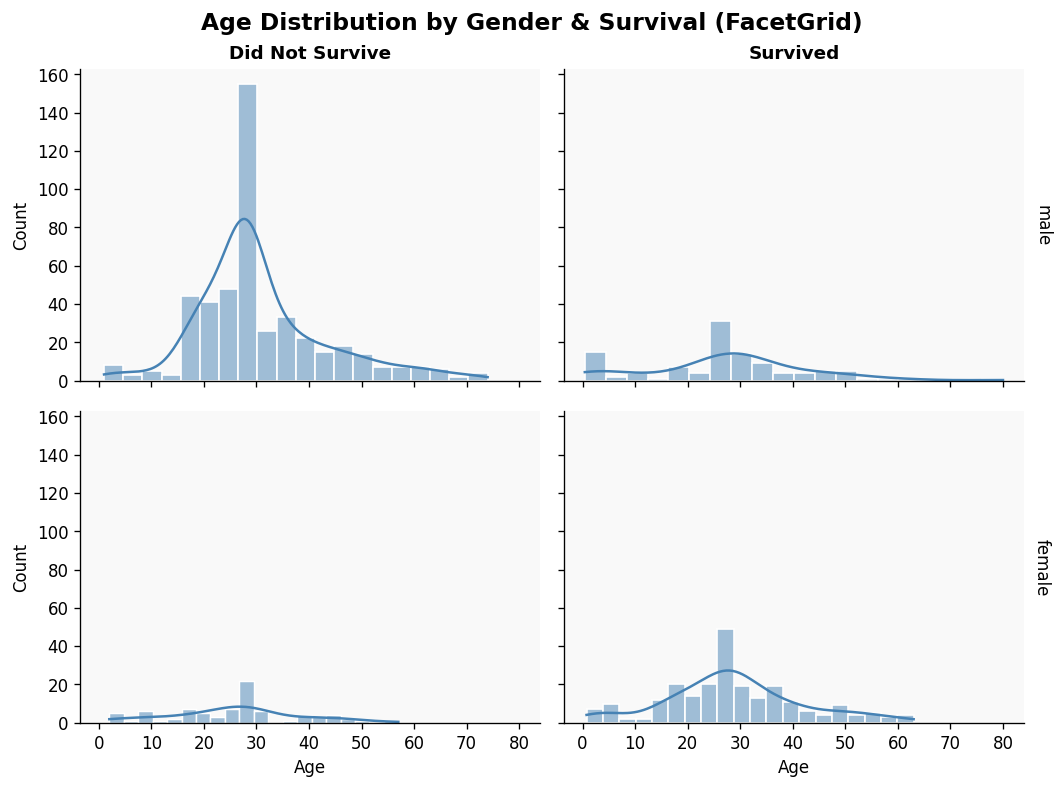

📊 Figure 12: FacetGrid — Age by Gender & Survival


In [27]:
# ── Fig 12: FacetGrid — Age distribution by Sex and Survival ──────────────────
g = sns.FacetGrid(df_clean, col='survived', row='sex',
                  margin_titles=True, height=3.2, aspect=1.4,
                  palette='Set2')
g.map(sns.histplot, 'age', bins=20, color='steelblue', edgecolor='white', kde=True)
g.set_axis_labels('Age', 'Count')
g.set_titles(col_template='{col_name}', row_template='{row_name}')

# Custom column titles
for ax, title in zip(g.axes[0], ['Did Not Survive', 'Survived']):
    ax.set_title(title, fontsize=11, fontweight='bold')

g.figure.suptitle('Age Distribution by Gender & Survival (FacetGrid)',
                   fontsize=14, fontweight='bold', y=1.02)
plt.savefig('fig12_facetgrid.png', bbox_inches='tight')
plt.show()
print('📊 Figure 12: FacetGrid — Age by Gender & Survival')

In [28]:
# ── Survival pivot table: Gender × Class ─────────────────────────────────────
pivot = df_clean.pivot_table(values='survived', index='sex',
                              columns='pclass', aggfunc='mean').round(3) * 100
pivot.columns = [f'Class {c} (%)' for c in pivot.columns]
print('Survival Rate (%) — Gender × Class:')
pivot.style.background_gradient(cmap='RdYlGn', vmin=0, vmax=100).format('{:.1f}%')

Survival Rate (%) — Gender × Class:


,Class 1 (%),Class 2 (%),Class 3 (%)
sex,,,
female,96.8%,92.1%,50.0%
male,36.9%,15.7%,13.5%


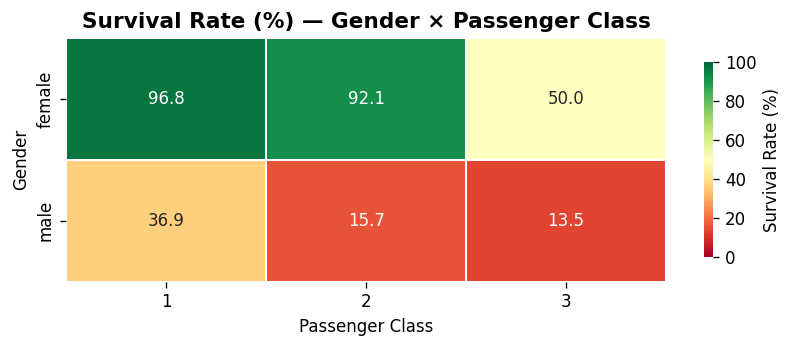

📊 Figure 13: Survival Rate Heatmap — Gender × Class


In [29]:
# ── Fig 13: Heatmap — Survival rate Gender × Class ────────────────────────────
raw_pivot = df_clean.pivot_table(values='survived', index='sex',
                                  columns='pclass', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(raw_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Survival Rate (%)', 'shrink': 0.8})
ax.set_title('Survival Rate (%) — Gender × Passenger Class',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Gender')
plt.tight_layout()
plt.savefig('fig13_gender_class_heatmap.png', bbox_inches='tight')
plt.show()
print('📊 Figure 13: Survival Rate Heatmap — Gender × Class')

> **Insight:**
> - **1st class women** had the highest survival rate (~97%) — almost guaranteed survival.
> - **3rd class men** had the lowest survival rate (~13%) — the worst odds on the ship.
> - Even **3rd class women (~50%)** had a better chance than **1st class men (~37%)**.

### 10.2 Family Size & Survival

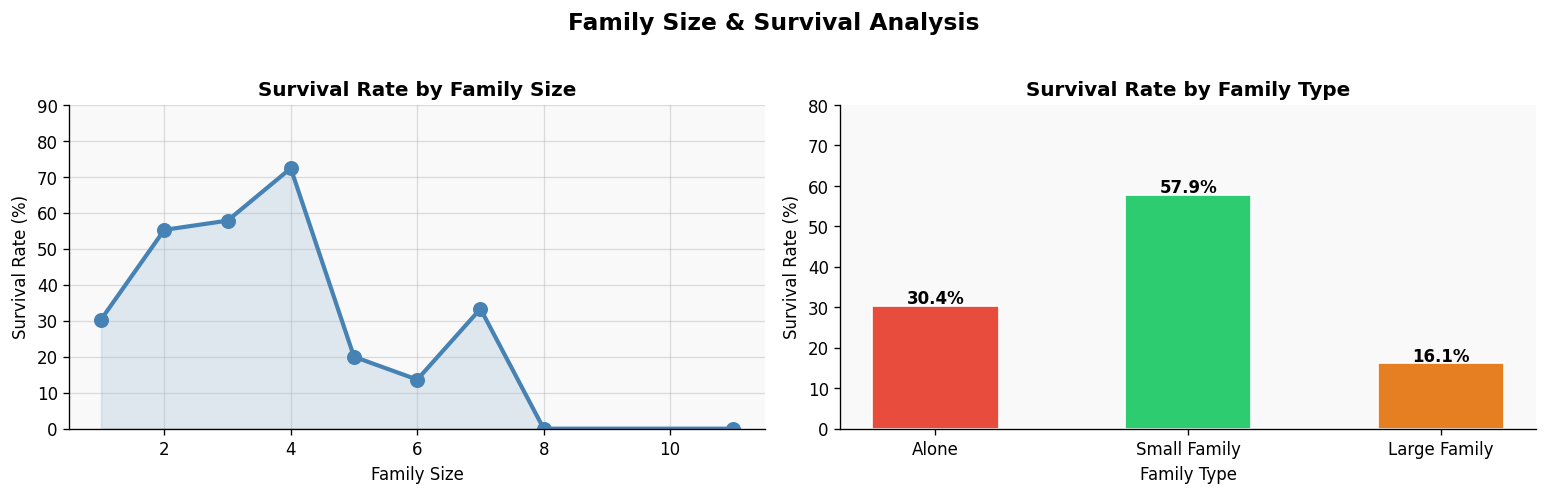

📊 Figure 14: Family Size vs Survival


In [30]:
# ── Create family size feature ────────────────────────────────────────────────
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1  # +1 for self
df_clean['family_type'] = pd.cut(df_clean['family_size'],
                                  bins=[0, 1, 4, 20],
                                  labels=['Alone', 'Small Family', 'Large Family'])

# ── Fig 14: Family size vs Survival rate ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fam_rate = df_clean.groupby('family_size')['survived'].mean().reset_index()
fam_rate['survived'] *= 100

axes[0].plot(fam_rate['family_size'], fam_rate['survived'],
             marker='o', linewidth=2.5, color='steelblue', markersize=8)
axes[0].fill_between(fam_rate['family_size'], fam_rate['survived'], alpha=0.15, color='steelblue')
axes[0].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 90)
axes[0].grid(True, alpha=0.4)

# Family type survival
type_rate = df_clean.groupby('family_type', observed=True)['survived'].mean().reset_index()
type_rate['survived'] *= 100
bars = axes[1].bar(type_rate['family_type'].astype(str), type_rate['survived'],
                   color=['#e74c3c', '#2ecc71', '#e67e22'], edgecolor='white', width=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Survival Rate by Family Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Family Type')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 80)

plt.suptitle('Family Size & Survival Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig14_family_survival.png', bbox_inches='tight')
plt.show()
print('📊 Figure 14: Family Size vs Survival')

> **Insight:** Passengers travelling in **small families (2–4 people)** had the highest survival rates. Those travelling **alone** or in **very large families (7+)** had much lower survival rates, possibly due to difficulty evacuating quickly as a group.

---
## 11. Key Insights & Final Conclusions <a id='11'></a>

> *A summary of everything discovered through our EDA.*

In [26]:
# ── Final summary statistics ──────────────────────────────────────────────────
total         = len(df_clean)
survived_pct  = df_clean['survived'].mean() * 100
female_surv   = df_clean[df_clean['sex']=='female']['survived'].mean() * 100
male_surv     = df_clean[df_clean['sex']=='male']['survived'].mean() * 100
c1_surv       = df_clean[df_clean['pclass']==1]['survived'].mean() * 100
c3_surv       = df_clean[df_clean['pclass']==3]['survived'].mean() * 100
child_surv    = df_clean[df_clean['age'] < 13]['survived'].mean() * 100

print('═' * 55)
print('   TITANIC EDA — FINAL SUMMARY')
print('═' * 55)
print(f'  Total passengers analysed  : {total}')
print(f'  Overall survival rate      : {survived_pct:.1f}%')
print(f'  Female survival rate       : {female_surv:.1f}%')
print(f'  Male survival rate         : {male_surv:.1f}%')
print(f'  1st Class survival rate    : {c1_surv:.1f}%')
print(f'  3rd Class survival rate    : {c3_surv:.1f}%')
print(f'  Children (<13) survival    : {child_surv:.1f}%')
print('═' * 55)

═══════════════════════════════════════════════════════
   TITANIC EDA — FINAL SUMMARY
═══════════════════════════════════════════════════════
  Total passengers analysed  : 891
  Overall survival rate      : 38.4%
  Female survival rate       : 74.2%
  Male survival rate         : 18.9%
  1st Class survival rate    : 63.0%
  3rd Class survival rate    : 24.2%
  Children (<13) survival    : 58.0%
═══════════════════════════════════════════════════════


---

## Conclusions

Based on our complete Exploratory Data Analysis of the Titanic dataset, here are the key conclusions:

---

### Dataset & Data Quality
1. **The dataset contains 891 passengers** with 15 original columns. After cleaning, we retained 14 usable columns (dropping `deck` due to 77%+ missing values).
2. **~20% of age values were missing** — imputed with the median (28 years) to avoid bias from outliers.
3. **No duplicate rows** were found in the dataset.

---

### Passenger Demographics
4. **Males outnumbered females** approximately 2:1 (~65% male, ~35% female).
5. **Over 55% of passengers travelled in 3rd class**, reflecting the ship's large immigration cargo.
6. **Most passengers embarked from Southampton (~72%)**, followed by Cherbourg (~19%) and Queenstown (~9%).
7. **Average passenger age was ~29.7 years**, with most passengers aged between 20 and 40.
8. **Fare was heavily right-skewed** — a small number of 1st class passengers paid extremely high fares (up to £512).

---

### Survival Patterns
9. **Only 38.4% of passengers survived** — less than 4 in 10 people on board made it out alive.
10. **Gender was the strongest predictor of survival**: females had a 74% survival rate vs only 19% for males — a difference of over 55 percentage points.
11. **Passenger class was the second-strongest predictor**: survival rates were 63% (1st), 47% (2nd), and just 24% (3rd class).
12. **1st class females had a ~97% survival rate** — near-guaranteed survival — while **3rd class males had only ~13%**.
13. **Children (under 13) had a ~59% survival rate**, the highest among all age groups, supporting the "women and children first" evacuation doctrine.
14. **Seniors (60+) had the lowest survival rate** among age groups, likely due to reduced mobility and lower priority in evacuation.
15. **Small family groups (2–4 members)** survived at higher rates than solo passengers or large families — suggesting family support aided evacuation.
16. **Higher fares correlated positively with survival** — 1st class cabins were closer to lifeboats and passengers had faster access to the upper decks.

---

### Overall Takeaway

> The Titanic disaster was **not random** in its death toll. Survival was systematically influenced by **gender, socioeconomic class, age, and family structure**. The data vividly reflects the class hierarchies and social norms of the early 20th century, where wealth and gender determined who lived and who died.

---
